In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

# Check if dataset is in the right place
base_path = 'UCI HAR Dataset'

print("Checking dataset structure...")
for item in os.listdir(base_path):
    print(f"  {item}")

Checking dataset structure...
  .DS_Store
  activity_labels.txt
  features.txt
  features_info.txt
  README.txt
  test
  train


In [3]:
# Load feature names
features = pd.read_csv('UCI HAR Dataset/features.txt', 
                        sep='\s+', header=None, names=['id', 'feature'])
feature_names = features['feature'].tolist()

# Load activity labels
activities = pd.read_csv('UCI HAR Dataset/activity_labels.txt',
                          sep='\s+', header=None, names=['id', 'activity'])
print("Activities:")
print(activities)

# Load training data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt',
                       sep='\s+', header=None, names=feature_names)
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt',
                       sep='\s+', header=None, names=['activity'])

# Load test data
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt',
                      sep='\s+', header=None, names=feature_names)
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt',
                      sep='\s+', header=None, names=['activity'])

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Activities:
   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


ValueError: Duplicate names are not allowed.

In [4]:
# Load feature names and make them unique
features = pd.read_csv('UCI HAR Dataset/features.txt', 
                        sep='\s+', header=None, names=['id', 'feature'])

# Make duplicate names unique by adding a number suffix
feature_names = []
name_count = {}
for name in features['feature'].tolist():
    if name in name_count:
        name_count[name] += 1
        feature_names.append(f"{name}_{name_count[name]}")
    else:
        name_count[name] = 0
        feature_names.append(name)

# Load training data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt',
                       sep='\s+', header=None, names=feature_names)
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt',
                       sep='\s+', header=None, names=['activity'])

# Load test data
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt',
                      sep='\s+', header=None, names=feature_names)
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt',
                      sep='\s+', header=None, names=['activity'])

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training samples: 7352
Test samples: 2947
Features: 561


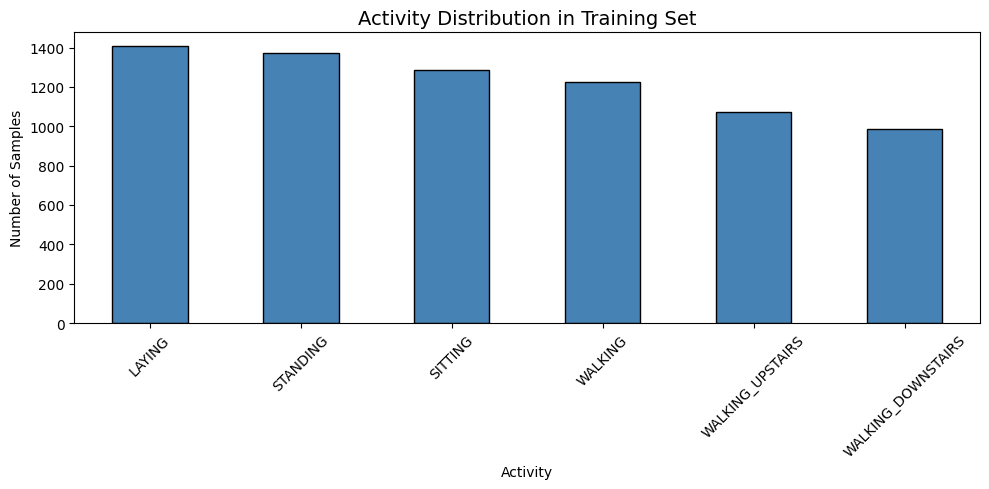

Activity counts:
activity_name
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


In [5]:

activity_map = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}

y_train['activity_name'] = y_train['activity'].map(activity_map)
y_test['activity_name'] = y_test['activity'].map(activity_map)


plt.figure(figsize=(10, 5))
y_train['activity_name'].value_counts().plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)
plt.title('Activity Distribution in Training Set', fontsize=14)
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Activity counts:")
print(y_train['activity_name'].value_counts())

In [6]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train['activity'])
y_test_encoded = le.transform(y_test['activity'])


print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, 
                                   n_jobs=-1)
rf_model.fit(X_train, y_train_encoded)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test_encoded, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")


print("\nTraining Gradient Boosting...")
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, 
                            random_state=42,
                            verbosity=0,
                            eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test_encoded, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

Training Random Forest...
Random Forest Accuracy: 0.9257

Training Gradient Boosting...
XGBoost Accuracy: 0.9379


XGBoost Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.98      0.95       496
           2       0.92      0.93      0.93       471
           3       0.97      0.90      0.94       420
           4       0.94      0.85      0.89       491
           5       0.88      0.95      0.91       532
           6       1.00      1.00      1.00       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



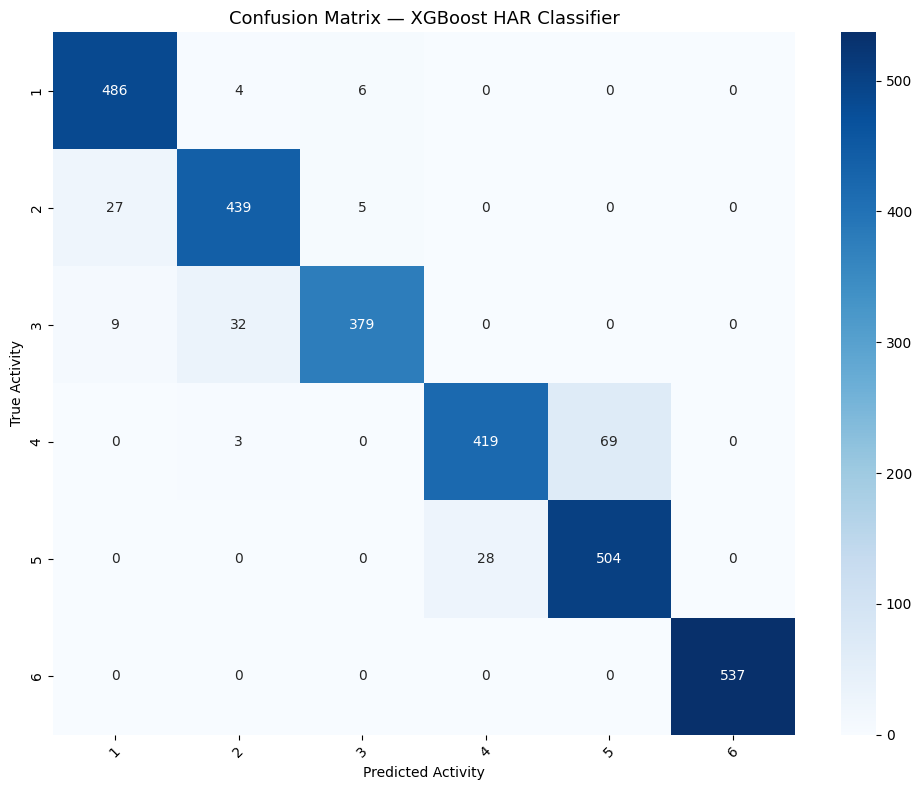

In [8]:
# Detailed classification report for best model (XGBoost)
activity_names = [str(x) for x in le.classes_]

print("XGBoost Classification Report:")
print(classification_report(y_test_encoded, xgb_pred,
                            target_names=activity_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names,
            yticklabels=activity_names)
plt.title('Confusion Matrix — XGBoost HAR Classifier', fontsize=13)
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

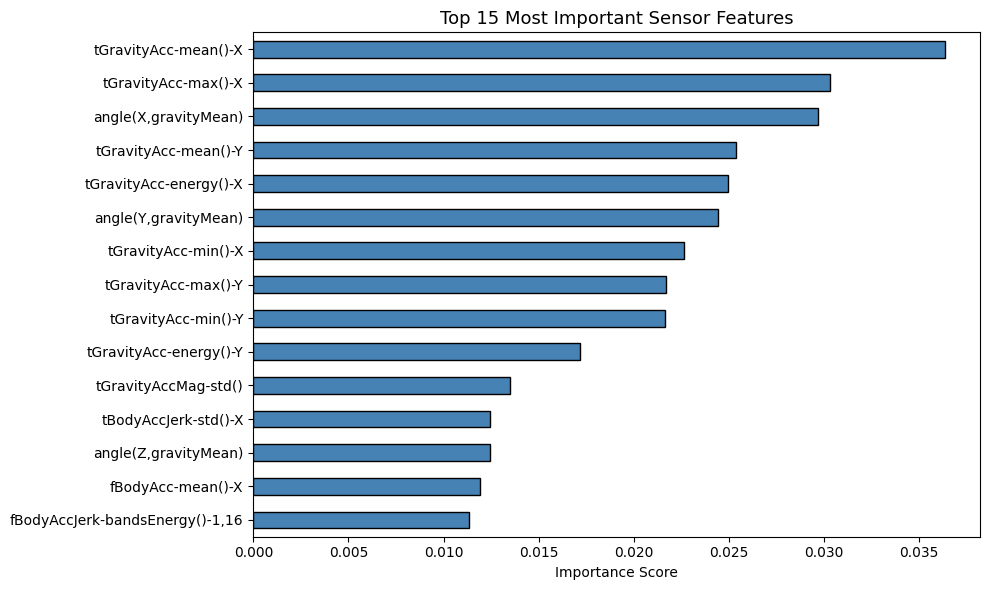

Top 5 most important features:
tGravityAcc-mean()-X      0.036380
tGravityAcc-max()-X       0.030331
angle(X,gravityMean)      0.029676
tGravityAcc-mean()-Y      0.025355
tGravityAcc-energy()-X    0.024963
dtype: float64


In [9]:

feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.head(15).plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Sensor Features', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(feat_importance.head())

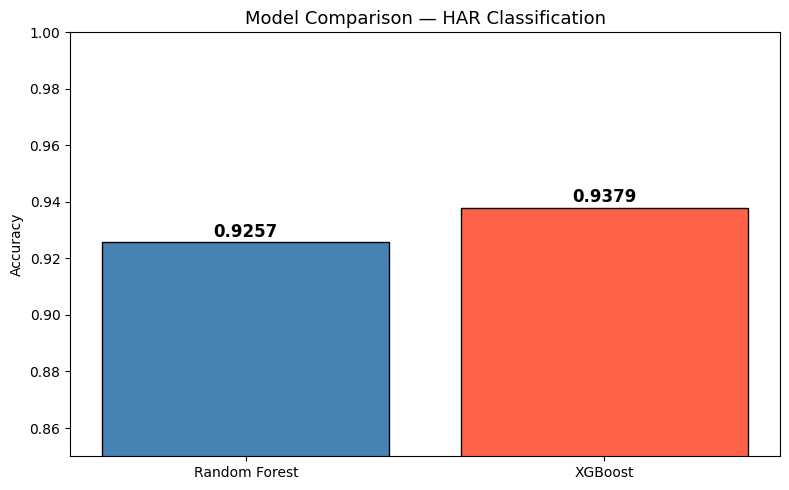

In [10]:
# Model comparison
models = ['Random Forest', 'XGBoost']
accuracies = [rf_acc, xgb_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, 
               color=['steelblue', 'tomato'],
               edgecolor='black')
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison — HAR Classification', fontsize=13)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}',
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:

# Subject 1, training data
raw_acc_x = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt',
    sep='\s+', header=None
)

raw_acc_y = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt',
    sep='\s+', header=None
)

raw_acc_z = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt',
    sep='\s+', header=None
)

print(f"Raw accelerometer shape: {raw_acc_x.shape}")
print("Each row = one 2.56 second window of 128 samples")

Raw accelerometer shape: (7352, 128)
Each row = one 2.56 second window of 128 samples


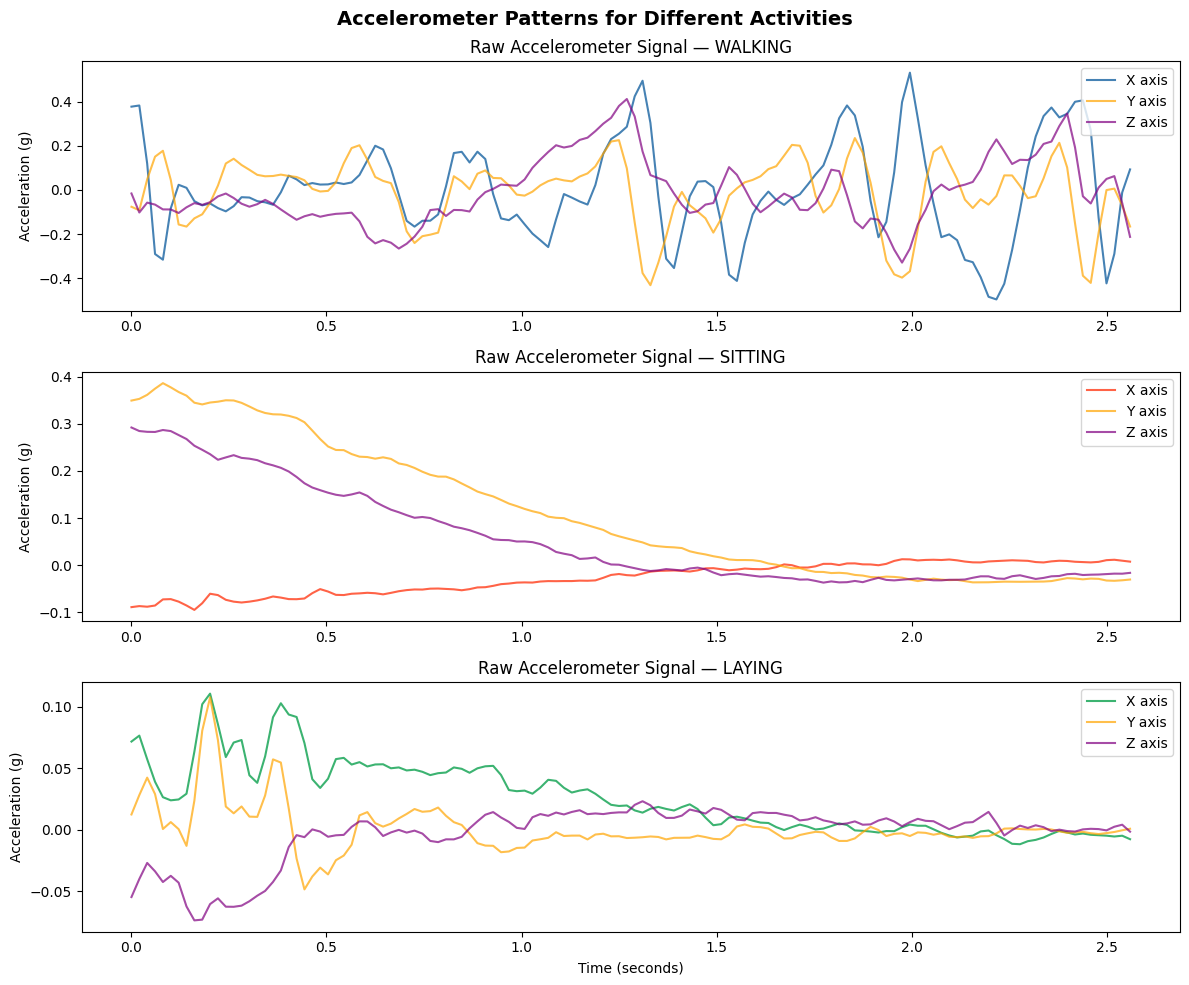

In [12]:

activity_indices = {
    'WALKING': y_train[y_train['activity'] == 1].index[0],
    'SITTING': y_train[y_train['activity'] == 4].index[0],
    'LAYING': y_train[y_train['activity'] == 6].index[0]
}

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
colors = ['steelblue', 'tomato', 'mediumseagreen']

for idx, (activity, sample_idx) in enumerate(activity_indices.items()):
    time_window = np.linspace(0, 2.56, 128)
    
    axes[idx].plot(time_window, raw_acc_x.iloc[sample_idx], 
                   color=colors[idx], linewidth=1.5, label='X axis')
    axes[idx].plot(time_window, raw_acc_y.iloc[sample_idx],
                   color='orange', linewidth=1.5, label='Y axis', alpha=0.7)
    axes[idx].plot(time_window, raw_acc_z.iloc[sample_idx],
                   color='purple', linewidth=1.5, label='Z axis', alpha=0.7)
    axes[idx].set_title(f'Raw Accelerometer Signal — {activity}', fontsize=12)
    axes[idx].set_ylabel('Acceleration (g)')
    axes[idx].legend(loc='upper right')

axes[2].set_xlabel('Time (seconds)')
plt.suptitle('Accelerometer Patterns for Different Activities', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:

subject_train = pd.read_csv(
    'UCI HAR Dataset/train/subject_train.txt',
    sep='\s+', header=None, names=['subject']
)

subject_test = pd.read_csv(
    'UCI HAR Dataset/test/subject_test.txt',
    sep='\s+', header=None, names=['subject']
)

print("Unique subjects in training:", sorted(subject_train['subject'].unique()))
print("Unique subjects in testing:", sorted(subject_test['subject'].unique()))
print(f"\nTraining subjects: {subject_train['subject'].nunique()}")
print(f"Testing subjects: {subject_test['subject'].nunique()}")

Unique subjects in training: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Unique subjects in testing: [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Training subjects: 21
Testing subjects: 9


In [15]:
print("Subject Independent Evaluation Protocol")
print("="*45)
print(f"Training subjects: 21 (IDs: 1,3,5,6,7,8,11,14,15,16,17,19,21,22,23,25,26,27,28,29,30)")
print(f"Testing subjects:  9  (IDs: 2,4,9,10,12,13,18,20,24)")
print(f"\nNo subject overlap between train and test sets.")
print(f"This confirms results generalise to unseen individuals.")
print(f"\nXGBoost Accuracy on unseen subjects: {xgb_acc:.4f}")
print(f"Random Forest Accuracy on unseen subjects: {rf_acc:.4f}")

Subject Independent Evaluation Protocol
Training subjects: 21 (IDs: 1,3,5,6,7,8,11,14,15,16,17,19,21,22,23,25,26,27,28,29,30)
Testing subjects:  9  (IDs: 2,4,9,10,12,13,18,20,24)

No subject overlap between train and test sets.
This confirms results generalise to unseen individuals.

XGBoost Accuracy on unseen subjects: 0.9379
Random Forest Accuracy on unseen subjects: 0.9257


In [16]:
readme_har = """# Human Activity Recognition from IMU Sensor Data

## Overview
A machine learning pipeline that classifies human physical activities 
using accelerometer and gyroscope data from smartphones. Directly applicable 
to clinical gait analysis, fall detection, and movement disorder monitoring 
in conditions such as Parkinson's disease.

## Results
| Model | Accuracy |
|-------|----------|
| Random Forest | 92.57% |
| XGBoost | 93.79% |

Evaluated using subject independent protocol — training and testing on 
completely different individuals, simulating real clinical deployment.

## Subject Independent Evaluation
| Split | Subjects | Samples |
|-------|----------|---------|
| Training | 21 subjects | 7,352 |
| Testing | 9 unseen subjects | 2,947 |

No subject overlap between train and test sets confirming the model 
generalises to individuals it has never seen before.

## Per-Activity Performance (XGBoost)
| Activity | F1-Score |
|----------|----------|
| LAYING | 1.00 |
| WALKING | 0.95 |
| WALKING_DOWNSTAIRS | 0.94 |
| WALKING_UPSTAIRS | 0.93 |
| STANDING | 0.91 |
| SITTING | 0.89 |

## Key Findings
1. SITTING and STANDING were hardest to distinguish (F1: 0.89 and 0.91)
   Both activities produce similar low-magnitude acceleration patterns
   since the person is relatively still — consistent with known challenges
   in static activity recognition.

2. Raw accelerometer analysis reveals distinct signal patterns:
   - WALKING: high amplitude oscillating signals from rhythmic foot strikes
   - SITTING: signals settle from high to near-zero as body stabilises
   - LAYING: very low amplitude flat signals indicating minimal movement

3. Gravity acceleration components (tGravityAcc-mean()-X, tGravityAcc-max()-X)
   were the strongest predictors — body orientation relative to gravity
   is the primary discriminator between activities.

## Clinical Relevance
This project demonstrates the core methodology behind:
- Fall detection systems for elderly patients
- Gait analysis for Parkinson's disease monitoring
- Rehabilitation progress tracking
- Remote patient monitoring via wearable sensors

## Dataset
- Source: UCI Machine Learning Repository
- 30 subjects, ages 19-48
- Sampled at 50Hz using Samsung Galaxy S2
- 7,352 training samples, 2,947 test samples
- 561 features extracted from accelerometer and gyroscope signals
- Link: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

## Pipeline
1. Load raw accelerometer and gyroscope features from UCI HAR Dataset
2. Visualize raw accelerometer signals per activity category
3. Train and compare Random Forest and XGBoost classifiers
4. Evaluate using subject independent protocol
5. Analyze per-activity F1 scores and feature importance

## Technologies
- Python 3.13
- pandas, numpy
- scikit-learn, XGBoost
- matplotlib, seaborn
- Jupyter Notebook

## How to Reproduce
1. Clone this repository
2. pip install -r requirements.txt
3. Download UCI HAR Dataset from the link above
4. Place UCI HAR Dataset folder in project root directory
5. Run 01_har_classifier.ipynb sequentially

## Author
Kritika
B.Tech Biomedical Engineering
"""

with open('README.md', 'w') as f:
    f.write(readme_har)

print("README updated!")

README updated!
